In [26]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

## 1. Build the graph

In [2]:
# Zachary Karate Club

G = nx.karate_club_graph()

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 34
Number of edges: 78


In [3]:
G.nodes()

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33))

In [4]:
G.edges()

EdgeView([(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10), (5, 16), (6, 16), (8, 30), (8, 32), (8, 33), (9, 33), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (18, 32), (18, 33), (19, 33), (20, 32), (20, 33), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 25), (24, 27), (24, 31), (25, 31), (26, 29), (26, 33), (27, 33), (28, 31), (28, 33), (29, 32), (29, 33), (30, 32), (30, 33), (31, 32), (31, 33), (32, 33)])

In [5]:
G.nodes[0]

{'club': 'Mr. Hi'}

Each node has an attribute (the club it belongs to). This information will be used later.

In [6]:
# Check if the network is weighted

edges = G.edges(data=True)
edges

EdgeDataView([(0, 1, {'weight': 4}), (0, 2, {'weight': 5}), (0, 3, {'weight': 3}), (0, 4, {'weight': 3}), (0, 5, {'weight': 3}), (0, 6, {'weight': 3}), (0, 7, {'weight': 2}), (0, 8, {'weight': 2}), (0, 10, {'weight': 2}), (0, 11, {'weight': 3}), (0, 12, {'weight': 1}), (0, 13, {'weight': 3}), (0, 17, {'weight': 2}), (0, 19, {'weight': 2}), (0, 21, {'weight': 2}), (0, 31, {'weight': 2}), (1, 2, {'weight': 6}), (1, 3, {'weight': 3}), (1, 7, {'weight': 4}), (1, 13, {'weight': 5}), (1, 17, {'weight': 1}), (1, 19, {'weight': 2}), (1, 21, {'weight': 2}), (1, 30, {'weight': 2}), (2, 3, {'weight': 3}), (2, 7, {'weight': 4}), (2, 8, {'weight': 5}), (2, 9, {'weight': 1}), (2, 13, {'weight': 3}), (2, 27, {'weight': 2}), (2, 28, {'weight': 2}), (2, 32, {'weight': 2}), (3, 7, {'weight': 3}), (3, 12, {'weight': 3}), (3, 13, {'weight': 3}), (4, 6, {'weight': 2}), (4, 10, {'weight': 3}), (5, 6, {'weight': 5}), (5, 10, {'weight': 3}), (5, 16, {'weight': 3}), (6, 16, {'weight': 3}), (8, 30, {'weight': 3

The network is weighted, meaning that to each edge is associated a weight (or strength) of the relationship.

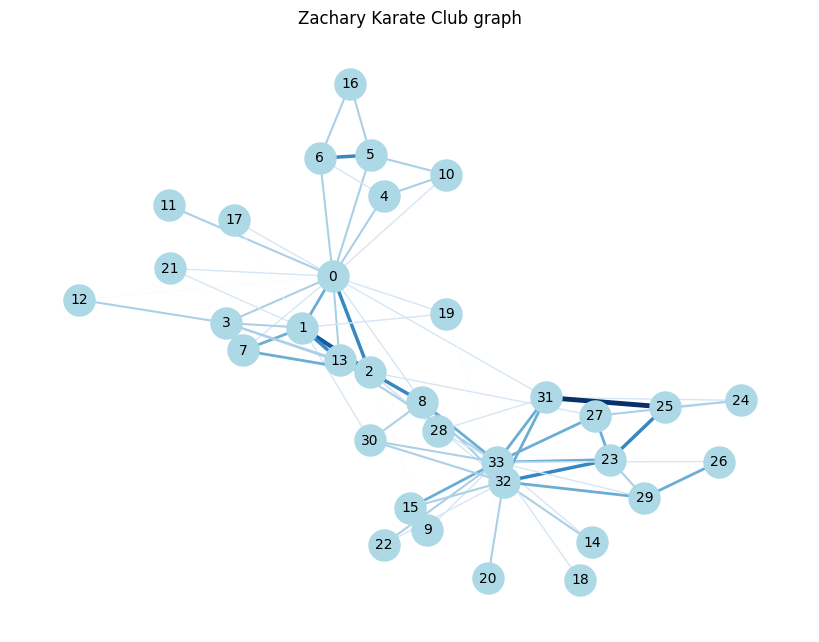

In [7]:
# Visualize the graph

weights = [G[u][v]["weight"] for u, v in G.edges()]

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    edge_color=weights,
    edge_cmap=plt.cm.Blues,
    width=[w*0.5 for w in weights],
    node_size=500,
    font_size=10
)

plt.title("Zachary Karate Club graph")
plt.show()

Nodes are people, while edges are relationships between them. I already notice 2 communities.

## 2. Adjacency matrix

In this matrix, $A_{ij}=weight_{ij}$ if a link exists between nodes $i$ and $j$ with a certain weight, and zero otherwise.

In [8]:
# Adj. matrix

A = nx.to_numpy_array(G)

print("Shape: ", A.shape)
print(A)

Shape:  (34, 34)
[[0. 4. 5. ... 2. 0. 0.]
 [4. 0. 6. ... 0. 0. 0.]
 [5. 6. 0. ... 0. 2. 0.]
 ...
 [2. 0. 0. ... 0. 4. 4.]
 [0. 0. 2. ... 4. 0. 5.]
 [0. 0. 0. ... 4. 5. 0.]]


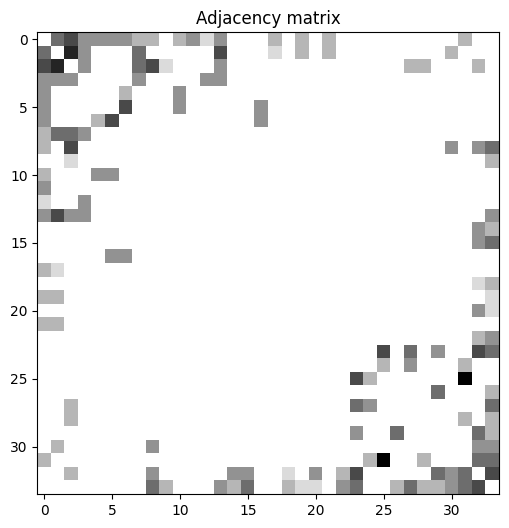

In [9]:
# Visualization

plt.figure(figsize=(6,6))
plt.imshow(A, cmap="binary")
plt.title("Adjacency matrix")
plt.show()

More dense "blocks" suggests the presence of communities.

In [10]:
# Simmetry

print(np.allclose(A, A.T))

True


In [11]:
# Degree 

degrees = A.sum(axis=1)
print(degrees)

[42. 29. 33. 18.  8. 14. 13. 13. 17.  3.  8.  3.  4. 17.  5.  7.  6.  3.
  3.  5.  4.  4.  5. 21.  7. 14.  6. 13.  6. 13. 11. 21. 38. 48.]


Some nodes have many weighted connections (up to 48), others much fewer.

## 3. Graph Laplacian

It transforms $A$ in such a way to capture the graph structure. In particular, $L=D-A$, where $D$ is the degree matrix.

In [12]:
# Degree matrix

D = np.diag(degrees)

In [13]:
# Laplacian

L = D - A
print(L)

[[42. -4. -5. ... -2.  0.  0.]
 [-4. 29. -6. ...  0.  0.  0.]
 [-5. -6. 33. ...  0. -2.  0.]
 ...
 [-2.  0.  0. ... 21. -4. -4.]
 [ 0.  0. -2. ... -4. 38. -5.]
 [ 0.  0.  0. ... -4. -5. 48.]]


In [14]:
# Checks

# 1. Simmetry
print(np.allclose(L, L.T))

# 2. Positive diagonal
print(np.all(np.diag(L) >= 0))

# 3. Sum rows around 0
print(np.allclose(L.sum(axis=1), 0))

True
True
True


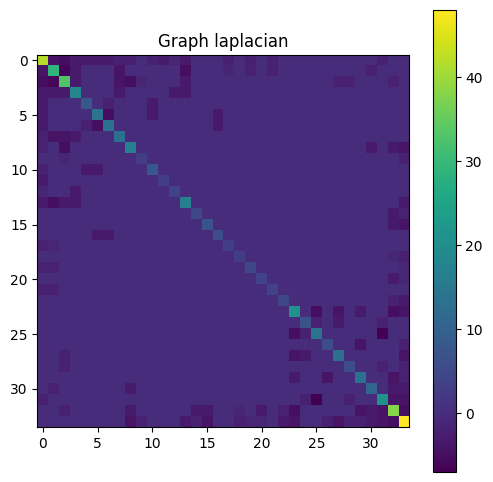

In [15]:
# Visualize

plt.figure(figsize=(6,6))
plt.imshow(L, cmap="viridis")
plt.title("Graph laplacian")
plt.colorbar()
plt.show()

Howver, I will use the normalized laplacian: $L_{norm} = D^{-1/2}LD^{-1/2}$

In [16]:
# Normalized laplacian

D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))
L_norm = D_inv_sqrt @ L @ D_inv_sqrt

The graph laplacian captures the structure of the network by combining:
* Node connectivity
* Information on the degree

Its eigenvectors reveal low-dimensional embeddings where clusters become separable.

## 4. Eigen-decomposition

I calculate eigenvalues and eigenvectors of the $L_{norm}$. In other words, I solve: $L_{norm}v = \lambda v$

In [17]:
# Eigen decomposition

eigenvalues, eigenvectors = np.linalg.eigh(L_norm)

idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:\n", eigenvalues[:10])

Eigenvalues:
 [1.41997424e-16 1.10074192e-01 2.47348878e-01 4.21459091e-01
 5.70464688e-01 6.45494390e-01 7.10863623e-01 7.38033652e-01
 7.79557552e-01 8.08276732e-01]


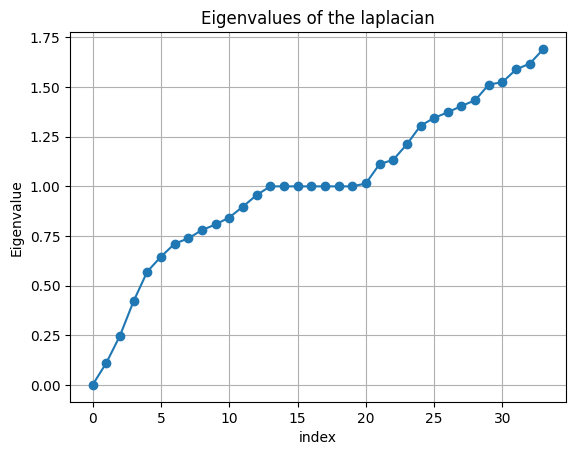

In [18]:
# Visualization

plt.plot(eigenvalues, marker="o")
plt.title("Eigenvalues of the laplacian")
plt.xlabel("index")
plt.ylabel("Eigenvalue")
plt.grid()
plt.show()

The separation into clusters is not very strong, as there are some bridge nodes.

I choose the first k eigenvectors.

In [19]:
k = 2

U = eigenvectors[:, :k]
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)

## 5. KMeans

In [21]:
# Clustering using KMeans

kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(U_norm)

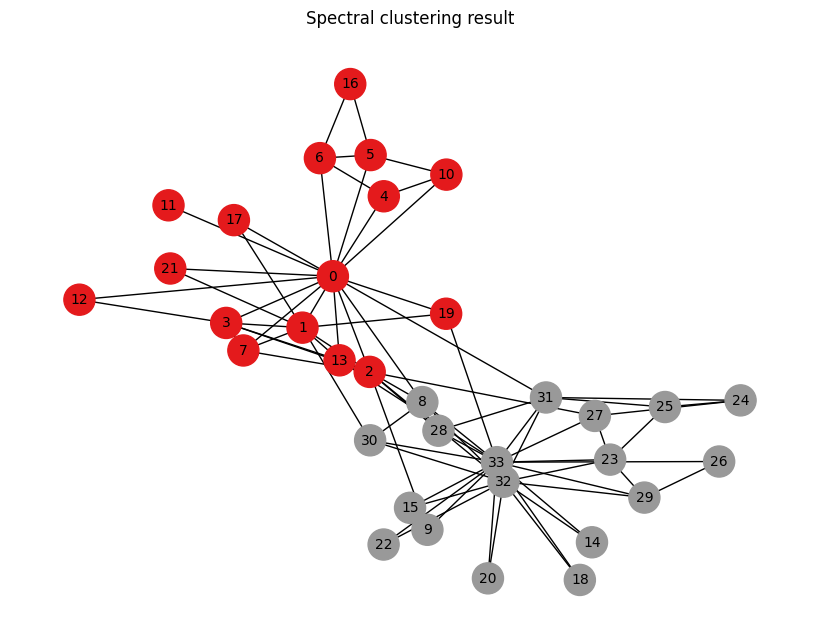

In [23]:
# Visualize

plt.figure(figsize=(8,6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=labels,
    cmap=plt.cm.Set1,
    node_size=500,
    font_size=10
)

plt.title("Spectral clustering result")
plt.show()

## 6. Comparison with real communities

In [24]:
# Get true labels 

true_labels = []

for node in G.nodes():
    club = G.nodes[node]["club"]
    true_labels.append(0 if club == "Mr. Hi" else 1)

true_labels = np.array(true_labels)

In [25]:
true_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [27]:
# Adjusted rand index

ari = adjusted_rand_score(true_labels, labels)
print(f"Adjusted Rand Index: {ari}")

Adjusted Rand Index: 0.8822575413558222


This score reveals that the found clustering is very close to the real one.

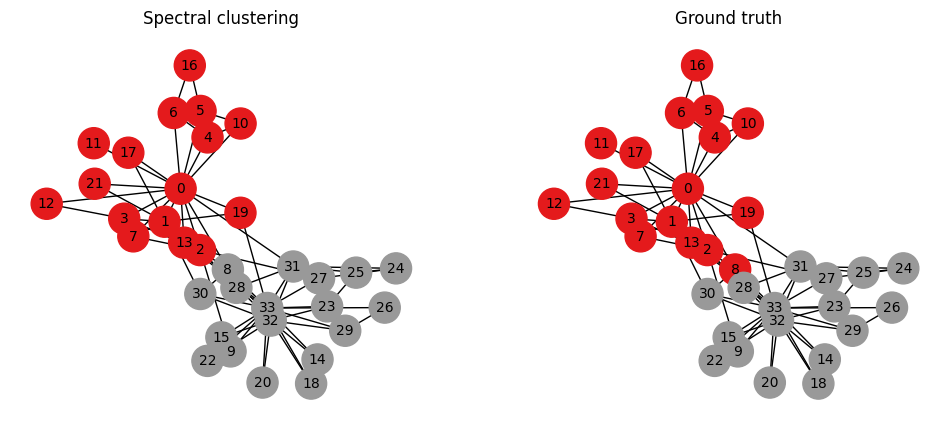

In [28]:
# Visualization for comparison

plt.figure(figsize=(12,5))

# Predicted
plt.subplot(1,2,1)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=labels,
    cmap=plt.cm.Set1,
    node_size=500,
    font_size=10
)
plt.title("Spectral clustering")

# True
plt.subplot(1,2,2)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=true_labels,
    cmap=plt.cm.Set1,
    node_size=500,
    font_size=10
)
plt.title("Ground truth")

plt.show()

The two graphs are very similar. The only thing that change is the bridge points.

In [29]:
# Misclassified points

misclassified = np.where(labels != true_labels)[0]
print("Misclassified points: ", misclassified)

Misclassified points:  [8]


There is actially just one misclassified point, and it is a bridge point.